In [2]:
import math, itertools, numpy as np, pandas as pd, pint_pandas, matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats

ureg       = pint_pandas.PintType.ureg # Consistent ureg between pint_pandas and declared values
dtime_conv = pd.to_timedelta(1, unit='s') # Multiplication/division converts deltatime values to float64 and vise-versa.
palette    = plt.rcParams['axes.prop_cycle'].by_key()['color'] # Pyplot standard color palette

# Converts Pint time values to Pandas deltatime.
def pint2dtime(times):
    return pd.to_timedelta(
        arg  = times.pint.magnitude,
        unit = str(times.dtype)[5:-1] # Strip "pint[...]" text wrapping the unit string.
    )

# Extracts event start times from Mecmesin event coding.
def event_times(event_coding):
    return event_coding[event_coding.diff() == -1].index

# Drops outlier values from series.
def drop_outliers(ser, std=3):
    return ser[stats.zscore(ser) < std]

# Labels each time with an associated state based on Mecmesin event start times.
# I.e. Labels each time with its Mecmesin cycle number and loading/unloading state.
def time2state(times, events):
    cycls      = pd.Series(pd.NA, times)
    cycls_time = pd.Series(pd.NA, times)
    for start, end, i in zip(events[::2], events[2::2], itertools.count()):
        mask = (times >= start) & (times < end)
        cycls[mask] = i
        start_aligned    = times[mask][0]
        cycls_time[mask] = (times[mask] - start_aligned) / dtime_conv

    loads      = pd.Series(pd.NA, times)
    loads_time = pd.Series(pd.NA, times)
    for start, end, i in zip(events, events[1:], itertools.count()):
        mask = (times >= start) & (times < end)
        loads[mask]      = i % 2
        start_aligned    = times[mask][0]
        loads_time[mask] = (times[mask] - start_aligned) / dtime_conv
    
    return cycls, cycls_time, loads, loads_time

# User inputs
mec_csv = 'data/2024-10-30/11.mec.31#1 1.5N 2mms 0 2.csv'
dmm_csv = 'data/2024-10-30/11.dmm.csv'
pressure_area = math.pi * (6.2 * ureg.mm / 2)**2

# Read and condition input data.
# Remove extraneous headers, add Pint units, add Pandas deltatime indices, offset DMM data by when it was triggered.
mec_df = pd.read_csv(mec_csv, header=[0,1], skiprows=[2,3]).dropna(how='all', axis='columns').rename(columns={'Unnamed: 3_level_1' : 'dimensionless'}).pint.quantify(level=-1)
dmm_df = pd.read_csv(dmm_csv, header=[0,1], index_col=[0]).pint.quantify(-1)
mec_df.index = pint2dtime(mec_df.Time)
events = event_times(mec_df.Event)
dmm_df.index = pint2dtime(dmm_df.Time) + events[0]

# Resample all data from time == 0 so Mecmesin and DMM data are aligned and concatenated.
# Sampling period is the max time between any two samples except for outliers (std=3).
# Outliers are excluded b/c DMM time has short but repeated spikes (~250 ms).
# Note negative offset when sampling to account for DMM time offset w/r/t Mecmesin.
# Pressure, cycle number, and loading/unloading state are appended.
# Rows with NaN values represent unaligned data and may be dropped as needed.
# CycleTime and LoadingTime record time since last cycle and loading state started
max_sample_time_denoised = max([drop_outliers(dmm_df.index.to_series().diff().dropna() / dtime_conv).max() * dtime_conv for df in [mec_df, dmm_df]])
df = pd.concat(
    [
        mec_df.resample(max_sample_time_denoised).mean()[['Force', 'Distance']],
        dmm_df.resample(max_sample_time_denoised, offset=-events[0]).mean()[['Resistance']]
    ],
    axis=1
)
df['Resistance'] = df.Resistance.pint.to(ureg.kohm)
df['Pressure'] = (df['Force'] / pressure_area).pint.to(ureg.kPa)
df['Cycle'], df['CycleTime'], df['Loading'], df['LoadingTime'] = time2state(df.index, events)

# Create Pint-unitless data copy to suppress Pyplot errors
dfdq = df.pint.dequantify() # Strip Pint units
dfdq.columns = dfdq.columns.droplevel(-1) # Remove unit headers from dequantify(). These cause problems with column access.

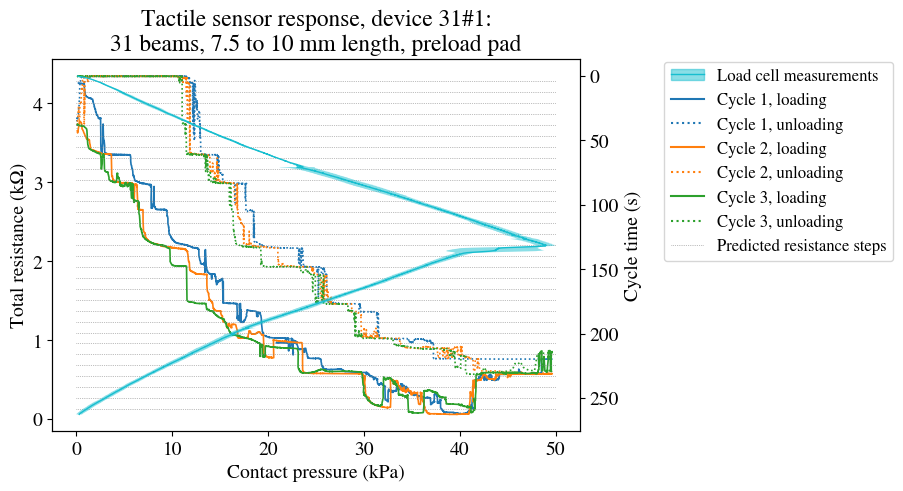

In [67]:
# Pyplot settings
mpl.rcParams['font.size'] = 14
# Use LaTeX font in Pyplot
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

# Study and plot these aligned data
groups = dfdq.dropna().groupby(['Cycle', 'Loading'])
fig, ax = plt.subplots(layout='constrained')
ax2 = ax.twinx()
lines = []

# Plot P/t with mean line and confidence std=3
cyc_df = pd.concat([df.set_index('CycleTime').Pressure for _, df in dfdq.dropna().groupby(['Cycle'])], axis=1).dropna()
cyc_mean, cyc_std = cyc_df.mean(axis=1), cyc_df.std(axis=1)
lines += ax2.plot(cyc_mean.values, cyc_mean.index, color=palette[-1], lw=1, label='Load cell measurements')
ax2.fill_betweenx(cyc_mean.index, cyc_mean + cyc_std, cyc_mean - cyc_std, facecolor=palette[-1], alpha=0.5)
cyc_fill_artist = ax2.fill(np.NaN, np.NaN, color=palette[-1], alpha=0.5) # Invisible artist so the fill_between shows in legend: https://stackoverflow.com/questions/26217687/combined-legend-entry-for-plot-and-fill-between

# Plot R/P
for (cycle, loading), gf in groups:
    lines += ax.plot(gf.Pressure, gf.Resistance, color=palette[cycle], linestyle=':' if gf.Loading.iloc[0] else '-', lw=1.2, label=f'Cycle {cycle+1}, {"unloading" if loading else "loading"}')

# Plot estimated resistance steps
num_beams = 31
samples, step = np.linspace(dfdq.Resistance.min(), dfdq.Resistance.max(), num=num_beams, endpoint=False, retstep=True)
ax.hlines(samples + step / 2, 0, 50, colors='gray', linestyles=':', lw=0.5)
lines += ax.plot(np.NaN, np.NaN, color='gray', linestyle=':', lw=0.5, label = 'Predicted resistance steps')

# Style axes
ax.title.set_text('Tactile sensor response, device 31#1:\n31 beams, 7.5 to 10 mm length, preload pad')
ax.set_ylabel('Total resistance (kΩ)')
ax2.set_ylabel('Cycle time (s)')
ax2.invert_yaxis()
ax.set_xlabel('Contact pressure (kPa)')

# Style legend
leg = fig.legend(
    [(cyc_fill_artist[0], lines[0])] + lines[1:], # Insert cyc_fill_artist into the legend via a tuple
    [l.get_label() for l in lines],
    bbox_transform=fig.transFigure,
    bbox_to_anchor=(1.4, 0.9),
    prop={
        'size' : 12,
    }
)
for legobj in leg.legend_handles[1:-1]: # Skip first index so cyc_fill_artist is unmodified
    legobj.set_linewidth(1.5)

plt.savefig('plot.png', dpi=600, bbox_inches='tight')
plt.show()